# 國立陽明交通大學 - 多模態影像資料處理 (MMIP) 2026 Fall
## Assignment 03：卷積神經網路（CNN）影像分類、遷移學習與可解釋性

- **學生**：林孟霆（`315833033`）
- **作業規範**：課程簡報第 79–81 頁（Quiz 1：15 分、Quiz 2：50 分、Quiz 3：35 分）
- **執行環境**：本 Notebook 的輸出為 Google Colab **Tesla T4 GPU** 上實際執行的結果
- **完整文字報告與結果分析**：請見同目錄 `README.md`

### 執行方式
- **Google Colab（T4 GPU）**：將 `HW03/` 壓縮成 `HW03.zip`，拖曳到 Colab 左側檔案區，執行階段選 **T4 GPU** 後依序執行所有 Cell。第一格會自動解壓縮並切換目錄；也支援把資料夾放在 Google Drive 的 `MyDrive/MMIP/HW03`。最後一格會把 `Output/` 與 `Checkpoints/` 打包下載。
- **本機**：直接在 `HW03/` 目錄啟動 Jupyter 執行；若 `Checkpoints/` 已有訓練好的模型，會直接讀取、不會重新訓練。

In [1]:
%matplotlib inline
# 環境設定：支援直接上傳 HW03.zip 或掛載 Google Drive
import os, sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # 方案 1 (免授權，最穩)：如果左側上傳了 HW03.zip，自動解壓並切換目錄
    if os.path.exists('/content/HW03.zip') and not os.path.exists('/content/HW03/Code'):
        !unzip -q -o /content/HW03.zip -d /content/
    
    if os.path.exists('/content/HW03'):
        os.chdir('/content/HW03')
        print("已使用 Colab 空間: /content/HW03")
    else:
        # 方案 2：嘗試讀取 Drive
        colab_dirs = [
            '/content/drive/MyDrive/MMIP/HW03',
            '/content/drive/MyDrive/mmip/HW03',
            '/content/drive/MyDrive/HW03',
        ]
        target_dir = next((d for d in colab_dirs if os.path.exists(d)), None)
        if target_dir:
            os.chdir(target_dir)
            print(f"已使用 Google Drive: {target_dir}")
        else:
            try:
                from google.colab import drive
                drive.mount('/content/drive')
                os.chdir('/content/drive/MyDrive/MMIP/HW03')
            except Exception as e:
                print(f"[提示] Google Drive 授權失敗或跳過 (若不想掛載 Drive，請直接把 HW03.zip 拖曳到左側檔案區！): {e}")

sys.path.insert(0, os.getcwd())

import torch
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from Code.data import load_cifar10, CLASS_NAMES
from Code.train import DEVICE

DATA_DIR, CKPT_DIR, OUT_DIR = 'Data', 'Checkpoints', 'Output'
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)
print(f"Working dir: {os.getcwd()}")
print(f"PyTorch {torch.__version__} | device: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})" if DEVICE.type == 'cuda' else ''))
data = load_cifar10(DATA_DIR)
print({k: tuple(v.shape) for k, v in data.items()})

已使用 Colab 空間: /content/HW03


Working dir: /content/HW03
PyTorch 2.11.0+cu128 | device: cuda (Tesla T4)


{'x_train': (45000, 3, 32, 32), 'y_train': (45000,), 'x_val': (5000, 3, 32, 32), 'y_val': (5000,), 'x_test': (10000, 3, 32, 32), 'y_test': (10000,)}


---
## Quiz 1：準備資料集（基礎 15 分）

**簡報要求（第 79 頁）**
1. （5 分）找到大型影像資料集，或自行準備影像資料集，並說明資料來源與內容。
2. （5 分）將資料集進行適當切分，建立訓練與驗證資料集，可採用 K-Fold Validation。
3. （5 分）描述影像分類的問題定義、資料類別與分類任務。

**本作業做法**
- **資料集**：CIFAR-10（Krizhevsky, 2009），60,000 張 32×32 彩色影像、10 個互斥類別，每類 6,000 張。官方來源 <https://www.cs.toronto.edu/~kriz/cifar.html>，本作業由原作者群（uoft-cs）上傳至 Hugging Face 的官方版本下載。
- **切分**：官方 50,000 張訓練集以分層抽樣（stratified，seed = 42）切出 45,000 張 **Training** 與 5,000 張 **Validation**；官方 10,000 張測試集作為 **Testing**，完全不參與訓練與模型挑選。K-Fold 需要把每個實驗重訓 K 次，在本作業 10 組實驗的規模下成本過高，因此採用分層的 Hold-out 切分。
- **問題定義**：單標籤、10 類別的影像分類。輸入為 3×32×32 的 RGB 影像，輸出為 10 個類別的機率分佈（Softmax），以 Cross-Entropy 作為損失函數，以 Top-1 / Top-5 Accuracy 與 Macro-AUC 評估。

QUIZ 1: DATASET PREPARATION (CIFAR-10)
Source : CIFAR-10 (Krizhevsky, 2009), official release by uoft-cs
Content: 60,000 RGB images, 32x32 px, 10 mutually exclusive classes
Split  : train 45000 | val 5000 (stratified from official train set, seed 42) | test 10000 (official test set)
class         train   val  test
airplane       4500   500  1000
automobile     4500   500  1000
bird           4500   500  1000
cat            4500   500  1000
deer           4500   500  1000
dog            4500   500  1000
frog           4500   500  1000
horse          4500   500  1000
ship           4500   500  1000
truck          4500   500  1000


[Saved] Output/quiz1_dataset_overview.png


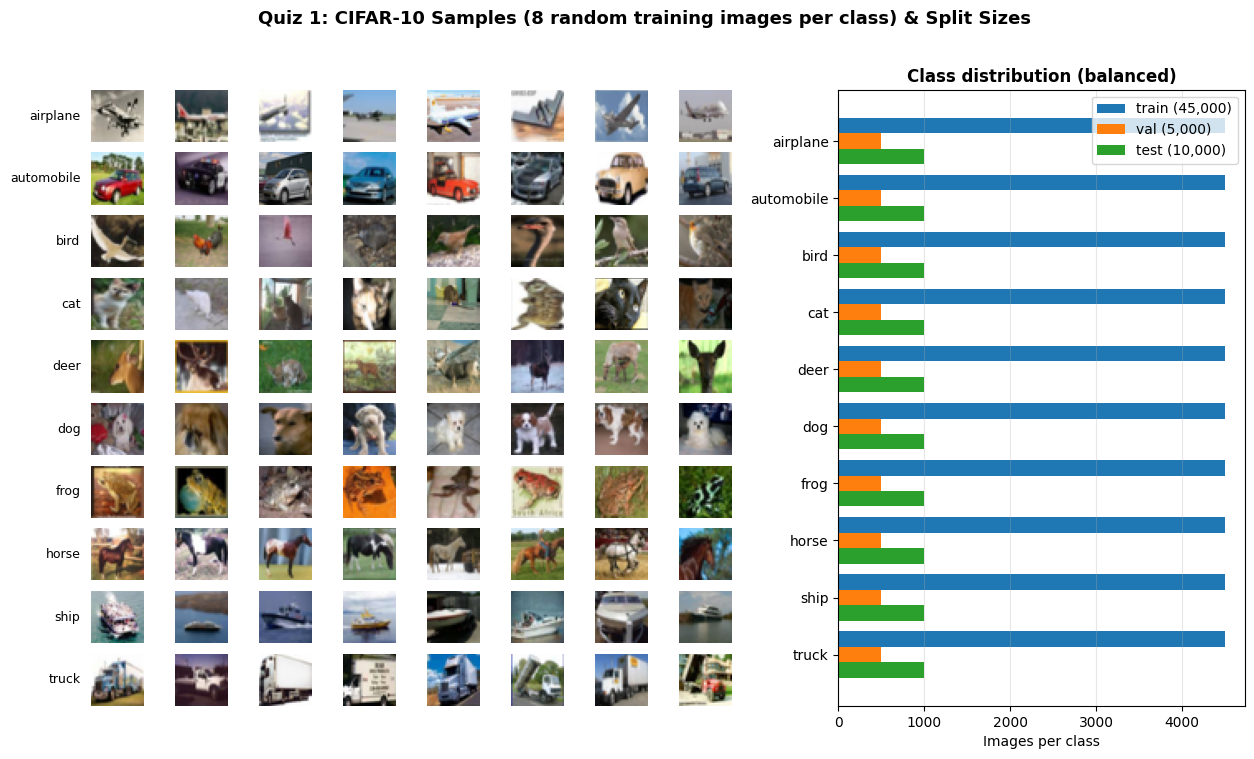

In [2]:
from Code.quiz1_dataset import run_quiz1
q1 = run_quiz1(data, OUT_DIR)

---
## Quiz 2：訓練 CNN 影像分類模型

### 基礎（30 分）— 簡報第 80 頁
- （9 分）自行設計一個 Plain CNN，完成模型訓練，並呈現 Top-1 / Top-5 Accuracy
- （3 分）使用 Plain CNN 預測 Testing Dataset，並整理預測結果
- （9 分）使用一個經典 CNN Backbone 完成模型訓練，並呈現 Top-1 / Top-5 Accuracy
- （3 分）使用經典 CNN 模型預測 Testing Dataset，並整理預測結果
- （6 分）繪製各類別的 ROC Curve，計算 Macro-AUC，並比較 Accuracy 表現與參數量大小

### 進階（20 分）
- （10 分）針對 Plain CNN 實驗不同的超參數設定，並說明實驗設計
- （10 分）針對經典 CNN Backbone 實驗不同的超參數設定，並說明實驗設計（Transfer Learning）

**模型**
- **Plain CNN（自行設計，無 Shortcut）**：3 個卷積區塊 `[Conv3×3-BN-ReLU]×2`（32 → 64 → 128 通道），前兩個區塊後接 MaxPool，最後 Global Average Pooling → Dropout(0.3) → Linear(10)。
- **經典 Backbone：ResNet-18**（He et al., 2015），載入 ImageNet 預訓練權重並換成 10 類別輸出層。ResNet-18 會把輸入縮小 32 倍，32×32 的影像到最後只剩 1×1 的特徵圖，因此先將影像放大到 64×64 再輸入。

**超參數**：Adam、Batch Size 128、Cross-Entropy；Plain CNN 學習率 1e-3、訓練 30 epochs；ResNet-18 微調學習率 1e-4、訓練 15 epochs。每個 epoch 結束都用 Validation 評估，並保留 Validation Accuracy 最高的權重，最後才用 Testing Dataset 評估一次。

下一格會訓練（或讀取已訓練好的）全部 Quiz 2 模型，T4 GPU 上約需 1 小時。

In [3]:
from Code.quiz2_cnn import run_quiz2
q2 = run_quiz2(data, CKPT_DIR, OUT_DIR)
plt.close('all')  # 圖表於下方各小題分別顯示

QUIZ 2 BASIC: PLAIN CNN vs RESNET-18


[cache] plain_baseline: loaded best-val checkpoint (epoch 23, val acc 0.8320)


[cache] resnet18_finetune_lr1e-4: loaded best-val checkpoint (epoch 15, val acc 0.8948)


                                      model  total_params  test_top1  test_top5  test_macro_auc  train_minutes
                                  Plain CNN        288746     0.8344     0.9917          0.9839            2.9
ResNet-18 (ImageNet-pretrained, fine-tuned)      11181642     0.8980     0.9961          0.9916            4.2



QUIZ 2 ADVANCED: HYPERPARAMETER / TRANSFER-LEARNING EXPERIMENTS
[cache] plain_baseline: loaded best-val checkpoint (epoch 23, val acc 0.8320)


...

[cache] resnet18_finetune_lr1e-4: loaded best-val checkpoint (epoch 15, val acc 0.8948)


[cache] resnet18_finetune_lr1e-3: loaded best-val checkpoint (epoch 14, val acc 0.8608)


[cache] resnet18_frozen_lr1e-3: loaded best-val checkpoint (epoch 14, val acc 0.7572)


[cache] resnet18_scratch_lr1e-3: loaded best-val checkpoint (epoch 10, val acc 0.7852)


    experiment  epochs  best_epoch  final_train_acc  best_val_acc  test_top1  test_top5  test_macro_auc  train_minutes  trainable_params
plain_baseline      30          23           0.9763        0.8320     0.8344     0.9917          0.9839            2.9            288746
  plain_lr1e-2      30          25           0.9749        0.8242     0.8329     0.9917          0.9831            2.9            288746
  plain_lr1e-4      30          30           0.9068        0.7772     0.7748     0.9861          0.9731            2.9            288746
plain_dropout0      30          30           0.9847        0.8144     0.8170     0.9910          0.9816            2.9            288746
              experiment  epochs  best_epoch  final_train_acc  best_val_acc  test_top1  test_top5  test_macro_auc  train_minutes  trainable_params
resnet18_finetune_lr1e-4      15          15           0.9955        0.8948     0.8980     0.9961          0.9916            4.2          11181642
resnet18_finetune_lr1

### Quiz 2 基礎：訓練曲線與 Top-1 / Top-5 Accuracy

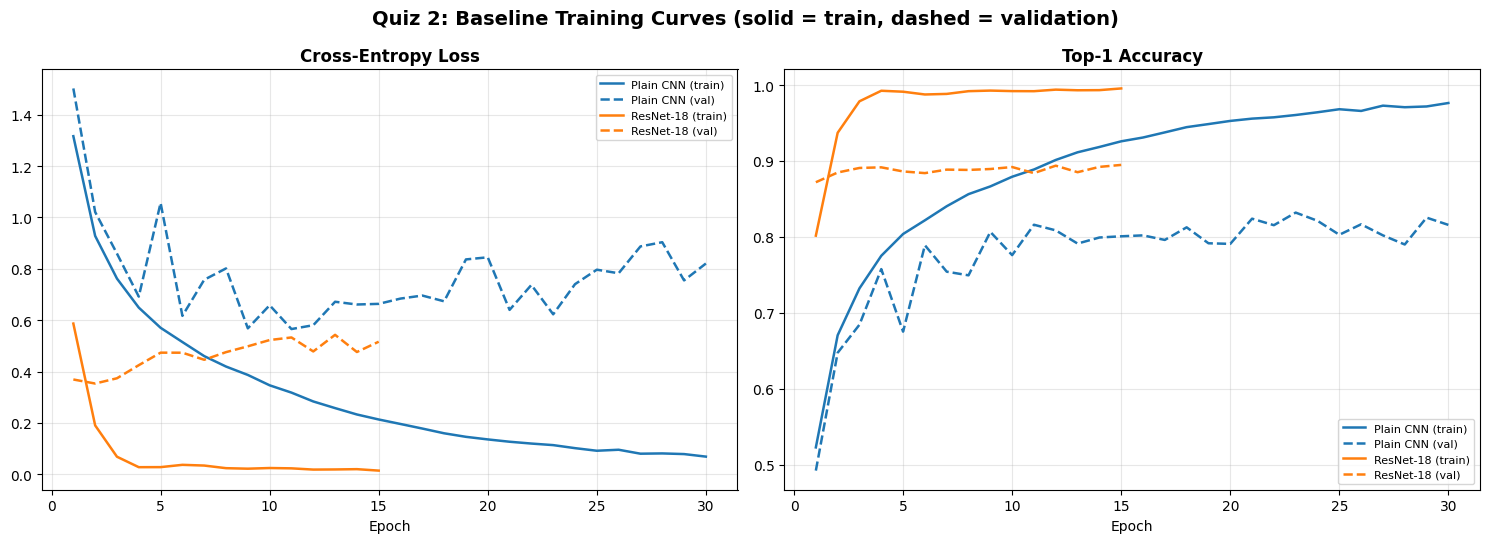

,model,total_params,best_epoch,best_val_acc,test_top1,test_top5,test_macro_auc,train_minutes
0,Plain CNN,288746,23,0.8320,0.8344,0.9917,0.9839,2.9
1,"ResNet-18 (ImageNet-pretrained, fine-tuned)",11181642,15,0.8948,0.8980,0.9961,0.9916,4.2


In [4]:
display(q2['figures']['curves'])
display(q2['comparison'][['model', 'total_params', 'best_epoch', 'best_val_acc', 'test_top1', 'test_top5', 'test_macro_auc', 'train_minutes']])

### Quiz 2 基礎：Testing Dataset 預測結果整理（完整逐張預測另存於 `Output/quiz2_*_test_predictions.csv`）

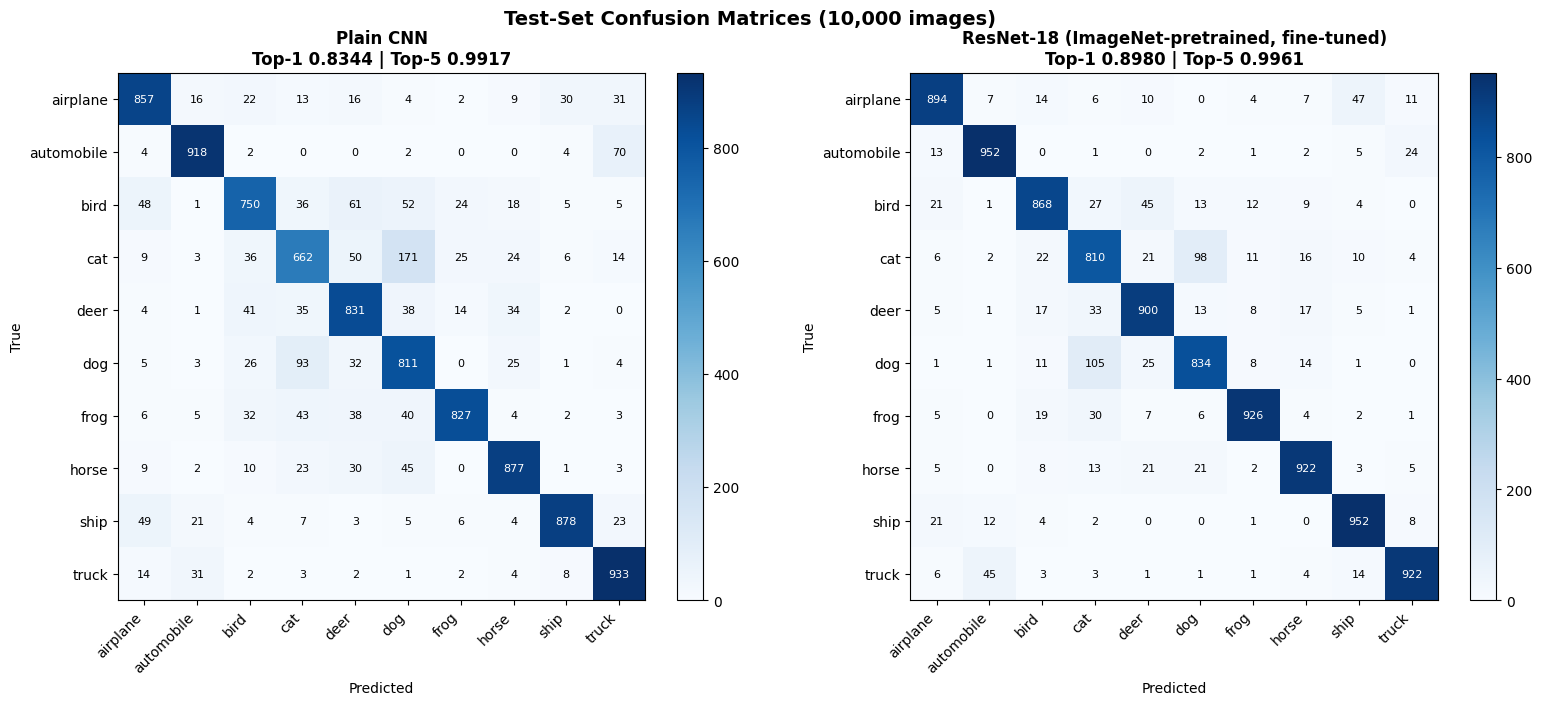

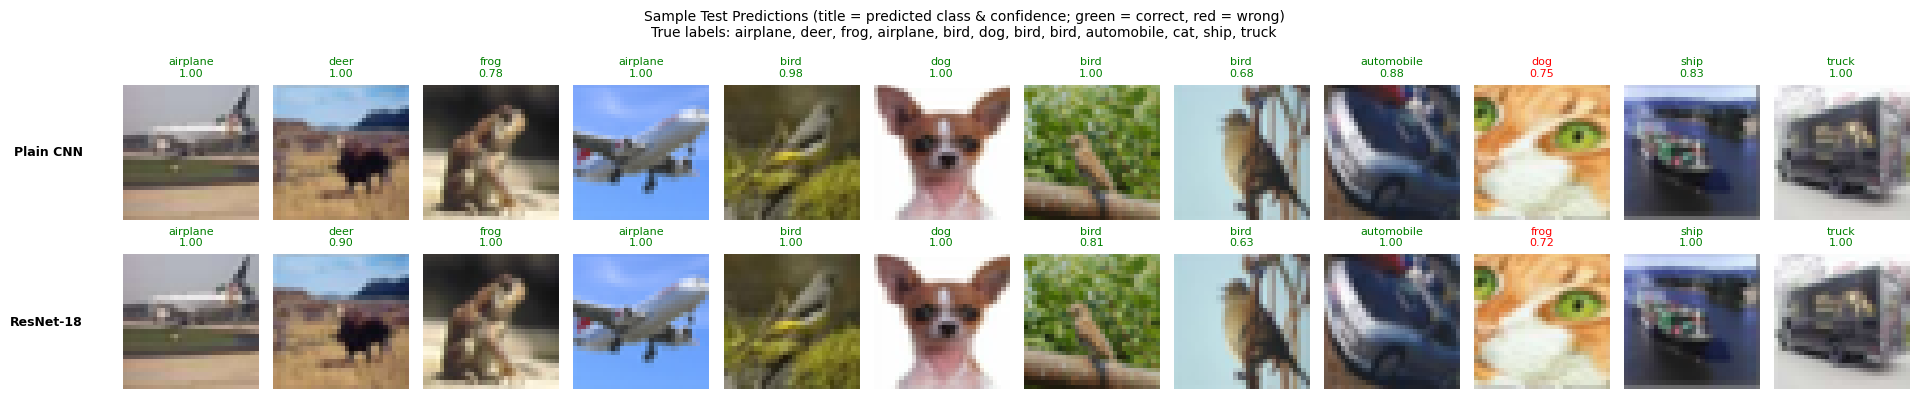

,class,top1_acc_plain,top5_acc_plain,auc_plain,top1_acc_resnet18,top5_acc_resnet18,auc_resnet18
0,airplane,0.857,0.994,0.9875,0.894,0.997,0.9943
1,automobile,0.918,0.995,0.9948,0.952,0.999,0.9969
2,bird,0.750,0.982,0.9722,0.868,0.997,0.9902
3,cat,0.662,0.998,0.9585,0.810,0.989,0.9755
4,deer,0.831,0.996,0.9832,0.900,0.999,0.9926
5,dog,0.811,0.994,0.9727,0.834,0.991,0.9836
6,frog,0.827,0.982,0.9896,0.926,0.996,0.9950
7,horse,0.877,0.991,0.9921,0.922,0.996,0.9953
8,ship,0.878,0.990,0.9939,0.952,0.998,0.9972
9,truck,0.933,0.995,0.9948,0.922,0.999,0.9956


Plain CNN 預測結果（前 10 筆）：


,index,true_label,pred_label,confidence,correct,top5
0,0,cat,cat,0.9868,True,"cat, automobile, truck, frog, ship"
1,1,ship,ship,0.7309,True,"ship, automobile, airplane, truck, frog"
2,2,ship,automobile,0.5731,False,"automobile, ship, truck, dog, cat"
3,3,airplane,airplane,0.6960,True,"airplane, ship, automobile, truck, bird"
4,4,frog,frog,1.0000,True,"frog, automobile, cat, deer, bird"
5,5,frog,frog,1.0000,True,"frog, cat, dog, deer, automobile"
6,6,automobile,truck,0.8937,False,"truck, automobile, horse, cat, airplane"
7,7,frog,bird,0.9066,False,"bird, frog, deer, horse, cat"
8,8,cat,cat,0.6755,True,"cat, dog, horse, deer, frog"
9,9,automobile,automobile,0.9766,True,"automobile, truck, ship, airplane, deer"


ResNet-18 預測結果（前 10 筆）：


,index,true_label,pred_label,confidence,correct,top5
0,0,cat,cat,0.9974,True,"cat, dog, bird, airplane, automobile"
1,1,ship,ship,0.9995,True,"ship, automobile, airplane, bird, horse"
2,2,ship,ship,0.9884,True,"ship, automobile, truck, airplane, horse"
3,3,airplane,airplane,0.9964,True,"airplane, bird, ship, truck, dog"
4,4,frog,frog,1.0000,True,"frog, bird, cat, deer, truck"
5,5,frog,frog,0.7338,True,"frog, dog, cat, truck, ship"
6,6,automobile,automobile,0.6911,True,"automobile, cat, truck, dog, horse"
7,7,frog,frog,1.0000,True,"frog, dog, automobile, cat, truck"
8,8,cat,cat,1.0000,True,"cat, dog, airplane, horse, automobile"
9,9,automobile,automobile,1.0000,True,"automobile, frog, truck, horse, ship"


In [5]:
display(q2['figures']['confusion'])
display(q2['figures']['samples'])
per_class = q2['plain_per_class'][['class', 'top1_acc', 'top5_acc', 'auc']].merge(
    q2['resnet_per_class'][['class', 'top1_acc', 'top5_acc', 'auc']], on='class', suffixes=('_plain', '_resnet18'))
display(per_class.round(4))
print('Plain CNN 預測結果（前 10 筆）：')
display(q2['plain_pred'].head(10))
print('ResNet-18 預測結果（前 10 筆）：')
display(q2['resnet_pred'].head(10))

### Quiz 2 基礎：各類別 ROC Curve、Macro-AUC 與參數量比較

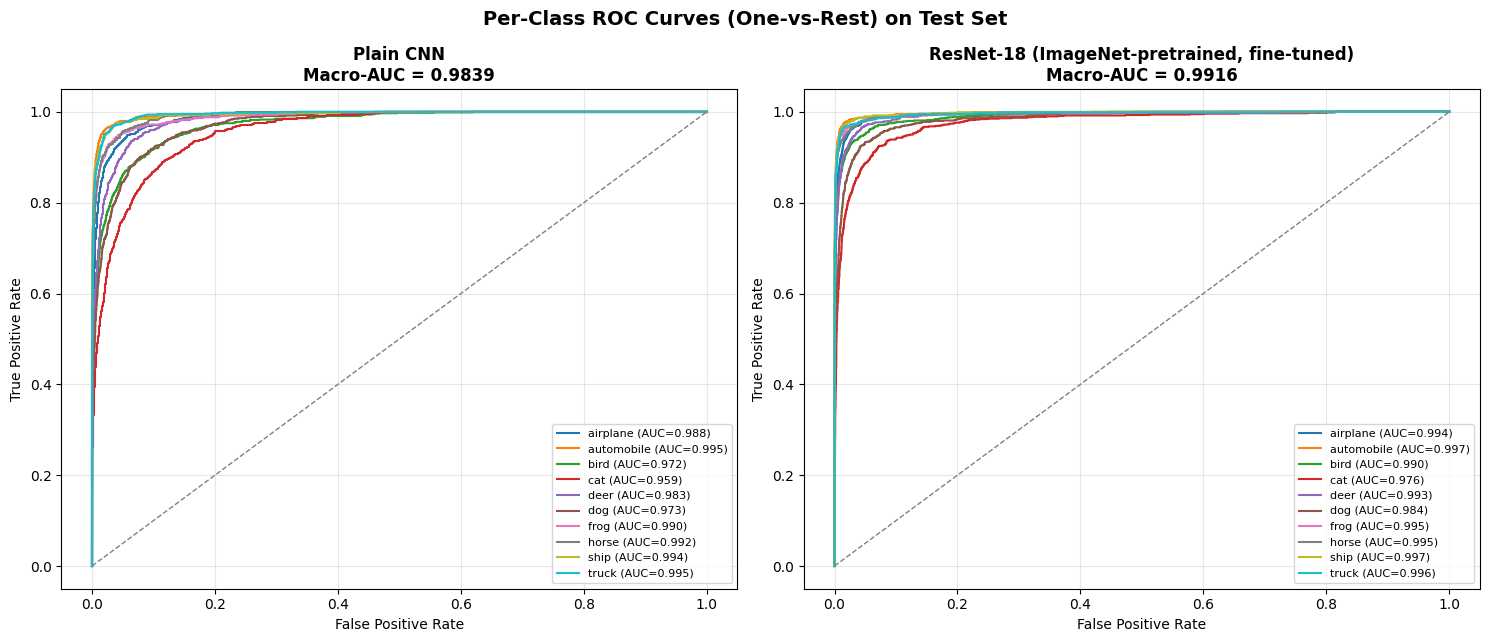

,model,total_params,test_top1,test_top5,test_macro_auc
0,Plain CNN,288746,0.8344,0.9917,0.9839
1,"ResNet-18 (ImageNet-pretrained, fine-tuned)",11181642,0.8980,0.9961,0.9916


In [6]:
display(q2['figures']['roc'])
display(q2['comparison'][['model', 'total_params', 'test_top1', 'test_top5', 'test_macro_auc']])

### Quiz 2 進階：超參數實驗設計（一次只改一個因素）

| 實驗 | 與基準相比只改變 | 想回答的問題 |
| :--- | :--- | :--- |
| `plain_baseline` | — | Plain CNN 基準（lr 1e-3、Dropout 0.3） |
| `plain_lr1e-2` | 學習率 ×10 | 學習率太大是否造成訓練不穩定？ |
| `plain_lr1e-4` | 學習率 ÷10 | 學習率太小是否在固定 epoch 內收斂不足？ |
| `plain_dropout0` | 移除 Dropout | 正則化對過擬合（train/val 差距）的影響 |
| `resnet18_finetune_lr1e-4` | — | ResNet-18 基準：ImageNet 預訓練 + 全部微調 |
| `resnet18_finetune_lr1e-3` | 微調學習率 ×10 | 太大的學習率是否破壞預訓練特徵？ |
| `resnet18_frozen_lr1e-3` | 凍結 Backbone，只訓練最後的 fc 層（與 lr1e-3 對照） | 只用預訓練特徵（Feature Extraction）能達到多少？ |
| `resnet18_scratch_lr1e-3` | 不載入預訓練權重（與 lr1e-3 對照） | 遷移學習相對於從頭訓練的效益 |

,experiment,epochs,best_epoch,final_train_acc,best_val_acc,test_top1,test_top5,test_macro_auc,train_minutes,trainable_params
0,plain_baseline,30,23,0.9763,0.8320,0.8344,0.9917,0.9839,2.9,288746
1,plain_lr1e-2,30,25,0.9749,0.8242,0.8329,0.9917,0.9831,2.9,288746
2,plain_lr1e-4,30,30,0.9068,0.7772,0.7748,0.9861,0.9731,2.9,288746
3,plain_dropout0,30,30,0.9847,0.8144,0.8170,0.9910,0.9816,2.9,288746


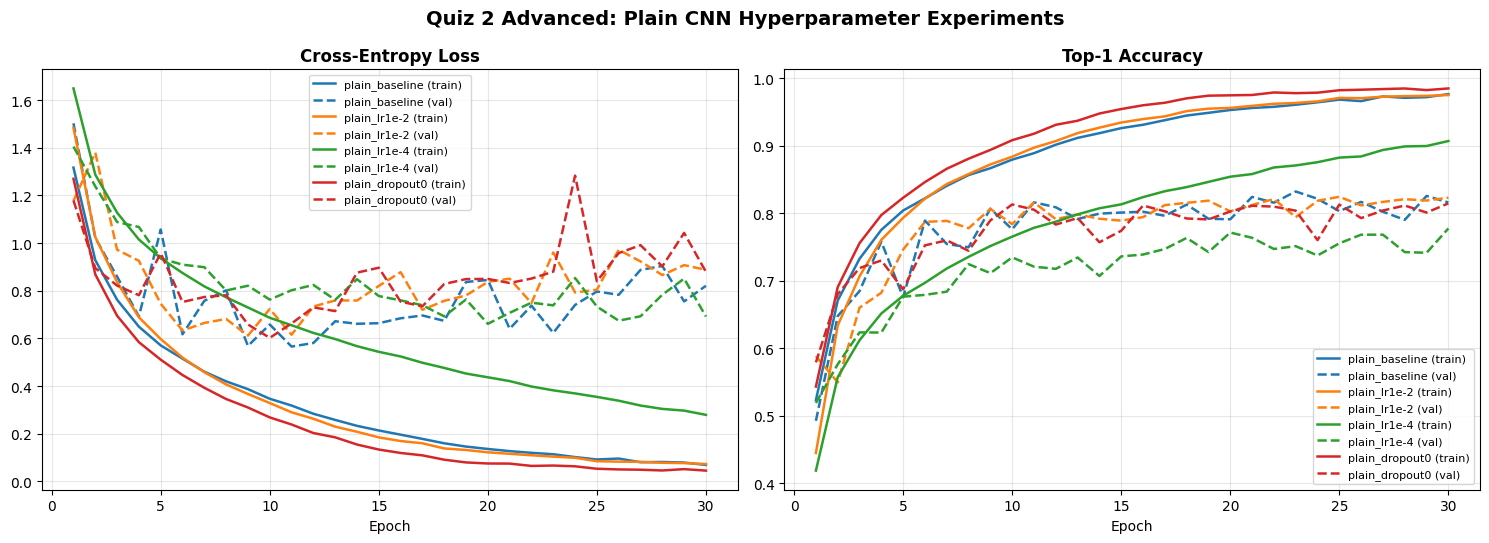

,experiment,epochs,best_epoch,final_train_acc,best_val_acc,test_top1,test_top5,test_macro_auc,train_minutes,trainable_params
0,resnet18_finetune_lr1e-4,15,15,0.9955,0.8948,0.8980,0.9961,0.9916,4.2,11181642
1,resnet18_finetune_lr1e-3,15,14,0.9844,0.8608,0.8579,0.9933,0.9884,4.2,11181642
2,resnet18_frozen_lr1e-3,15,14,0.7865,0.7572,0.7666,0.9862,0.9716,1.3,5130
3,resnet18_scratch_lr1e-3,15,10,0.9826,0.7852,0.7843,0.9859,0.9747,4.2,11181642


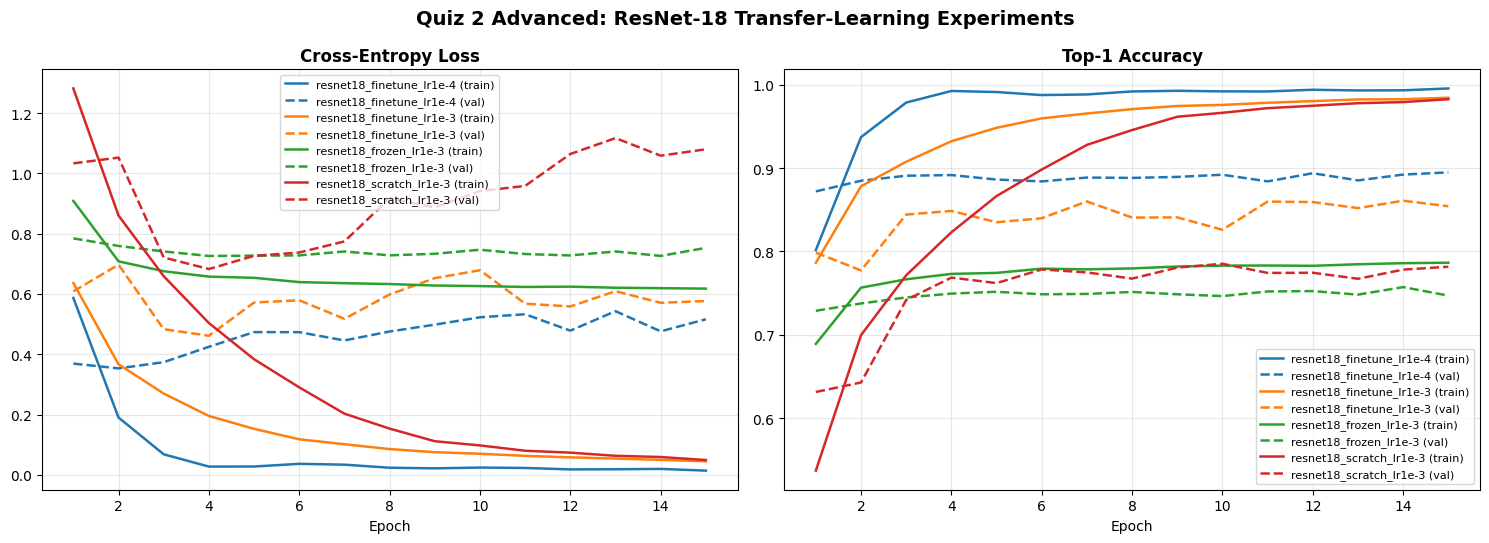

In [7]:
display(q2['plain_hparam'])
display(q2['figures']['plain_hparam'])
display(q2['resnet_hparam'])
display(q2['figures']['resnet_hparam'])

---
## Quiz 3：提升泛化能力

### 基礎（15 分）— 簡報第 81 頁
- （8 分）替自行設計的 Plain CNN 加入 Data Augmentation，比較前後表現，並說明擴增策略。
- （7 分）替經典的 CNN 加入 Data Augmentation，比較前後表現，並說明擴增策略。

**擴增策略**（只在訓練時使用，驗證與測試不做擴增；兩個模型用同一套策略，其餘設定與各自的基準完全相同）：
1. **Random Crop**：四周 reflect padding 4 像素後隨機裁回 32×32（最多平移 ±4 像素），讓模型不依賴物體的固定位置。
2. **Random Horizontal Flip**（p = 0.5）：左右翻轉不會改變 CIFAR-10 的類別；刻意**不做**垂直翻轉，因為倒過來的車子或動物不會出現在測試資料中。
3. **亮度 / 對比擾動**：每張影像各自乘上 [0.8, 1.2] 之間的隨機亮度與對比係數，模擬不同光照條件（對應簡報 AlexNet 的顏色擾動概念）。

QUIZ 3 BASIC: DATA AUGMENTATION
[cache] plain_baseline: loaded best-val checkpoint (epoch 23, val acc 0.8320)


[cache] plain_augment: loaded best-val checkpoint (epoch 30, val acc 0.8672)


[cache] resnet18_finetune_lr1e-4: loaded best-val checkpoint (epoch 15, val acc 0.8948)


[cache] resnet18_finetune_lr1e-4_augment: loaded best-val checkpoint (epoch 13, val acc 0.9202)


                      experiment  epochs  best_epoch  final_train_acc  best_val_acc  test_top1  test_top5  test_macro_auc  train_minutes  trainable_params  train_val_acc_gap
                  plain_baseline      30          23           0.9763        0.8320     0.8344     0.9917          0.9839            2.9            288746             0.1605
                   plain_augment      30          30           0.8920        0.8672     0.8661     0.9951          0.9902            4.4            288746             0.0248
        resnet18_finetune_lr1e-4      15          15           0.9955        0.8948     0.8980     0.9961          0.9916            4.2          11181642             0.1007
resnet18_finetune_lr1e-4_augment      15          13           0.9736        0.9202     0.9138     0.9976          0.9953            6.0          11181642             0.0572

QUIZ 3 ADVANCED: KERNEL VISUALISATION & GRAD-CAM


Kernel A #26: {'colour_ratio': 0.21206743270127215, 'orientation': 'horizontal edges (intensity changes top-bottom)', 'channel_mean_rgb': [0.0028, -0.0045, 0.0042], 'spatial_energy': 0.9225055250458265, 'mean_response_std': 4.4924}
Kernel B #23: {'colour_ratio': 0.9988887583783713, 'orientation': 'diagonal / mixed-direction structure', 'channel_mean_rgb': [-0.0013, -0.0033, 0.0002], 'spatial_energy': 0.06430629981887463, 'mean_response_std': 0.4518}


 index     model       true       pred  confidence  correct  centre_mass feature_map
  8777 Plain CNN   airplane   airplane       0.999     True        0.575         8x8
  8777 ResNet-18   airplane   airplane       0.999     True        0.102         4x4
  6371 Plain CNN automobile automobile       0.989     True        0.385         8x8
  6371 ResNet-18 automobile automobile       1.000     True        0.187         4x4
  5032 Plain CNN       bird       bird       1.000     True        0.578         8x8
  5032 ResNet-18       bird       bird       1.000     True        0.766         4x4
  2617 Plain CNN        cat        cat       1.000     True        0.520         8x8
  2617 ResNet-18        cat        cat       1.000     True        0.276         4x4
  3054 Plain CNN       deer       deer       1.000     True        0.638         8x8
  3054 ResNet-18       deer       deer       0.983     True        0.733         4x4
   389 Plain CNN        dog        dog       1.000     True      

,experiment,best_epoch,final_train_acc,best_val_acc,train_val_acc_gap,test_top1,test_top5,test_macro_auc
0,plain_baseline,23,0.9763,0.8320,0.1605,0.8344,0.9917,0.9839
1,plain_augment,30,0.8920,0.8672,0.0248,0.8661,0.9951,0.9902
2,resnet18_finetune_lr1e-4,15,0.9955,0.8948,0.1007,0.8980,0.9961,0.9916
3,resnet18_finetune_lr1e-4_augment,13,0.9736,0.9202,0.0572,0.9138,0.9976,0.9953


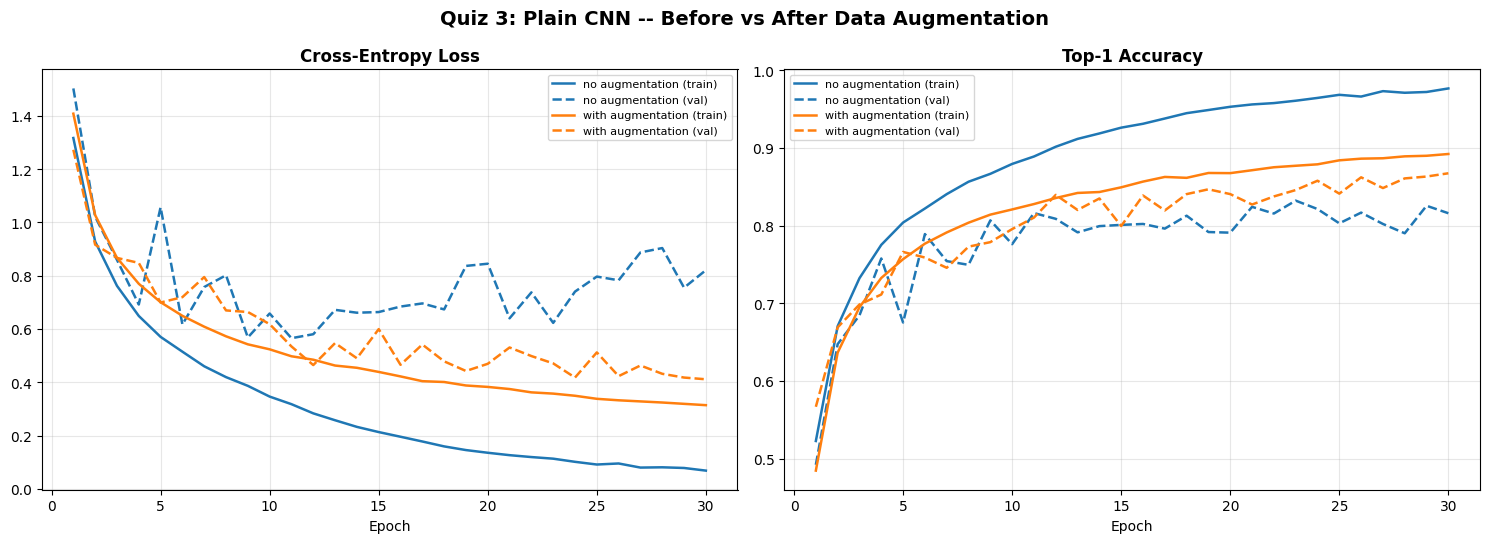

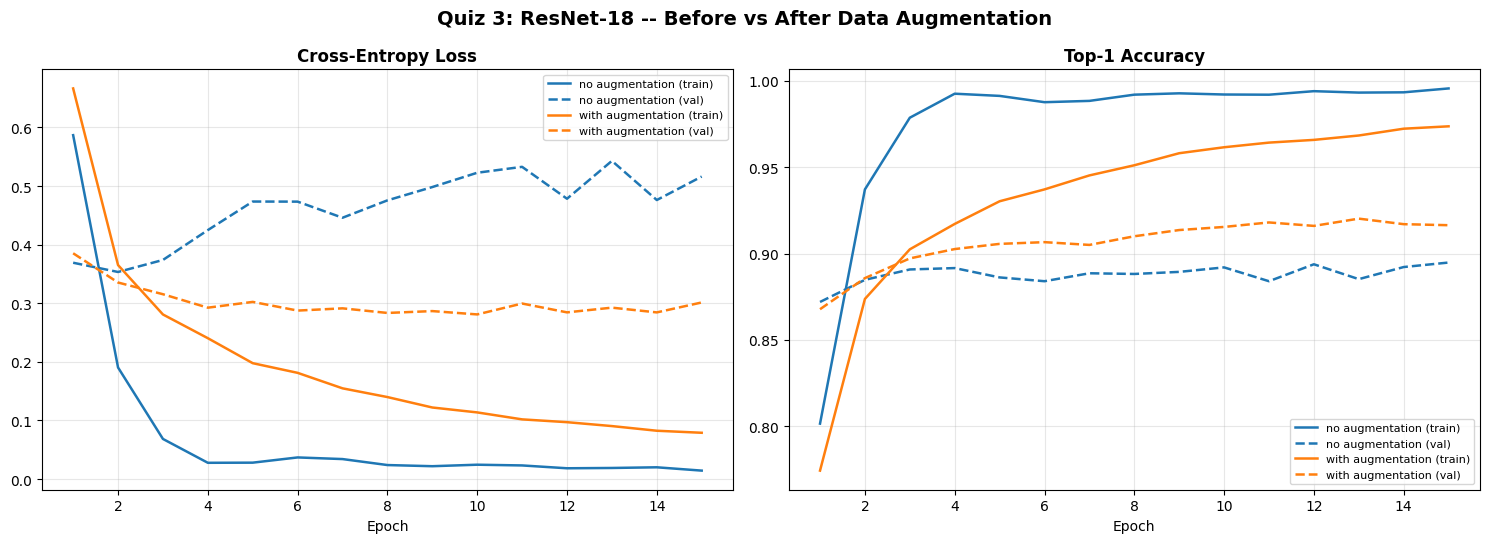

In [8]:
from Code.quiz3_generalization import run_quiz3
q3 = run_quiz3(data, CKPT_DIR, OUT_DIR)
plt.close('all')
display(q3['aug_table'][['experiment', 'best_epoch', 'final_train_acc', 'best_val_acc', 'train_val_acc_gap', 'test_top1', 'test_top5', 'test_macro_auc']])
display(q3['figures']['plain_aug'])
display(q3['figures']['resnet_aug'])

### 進階（20 分）
- （10 分）視覺化其中一個訓練後的 CNN 其中的兩個 Kernel，並嘗試分析其用途。
- （10 分）使用 XAI 方法解釋模型預測結果，並分析模型所關注的影像區域。

**Kernel 視覺化**：選用微調後 ResNet-18 的第一層卷積（64 個 7×7×3 kernel），並依照明確的規則自動挑出兩個 kernel，不是人工挑圖：
- **Kernel A（邊緣規則）**：在三個通道權重幾乎相同（colour ratio < 0.3，對顏色不敏感、只看明暗結構）的 kernel 中，選出在 1,000 張 Validation 影像上特徵圖反應起伏最大的一個（排除最外圈 3 像素的邊界效應）。
- **Kernel B（色彩規則）**：R/G/B 三個通道權重差異最大的 kernel，也就是會對顏色差異起反應的 kernel。

圖中同時畫出每個 kernel 的 R/G/B 權重（紅 = 正、藍 = 負）以及它在同一張測試影像上的特徵圖反應。

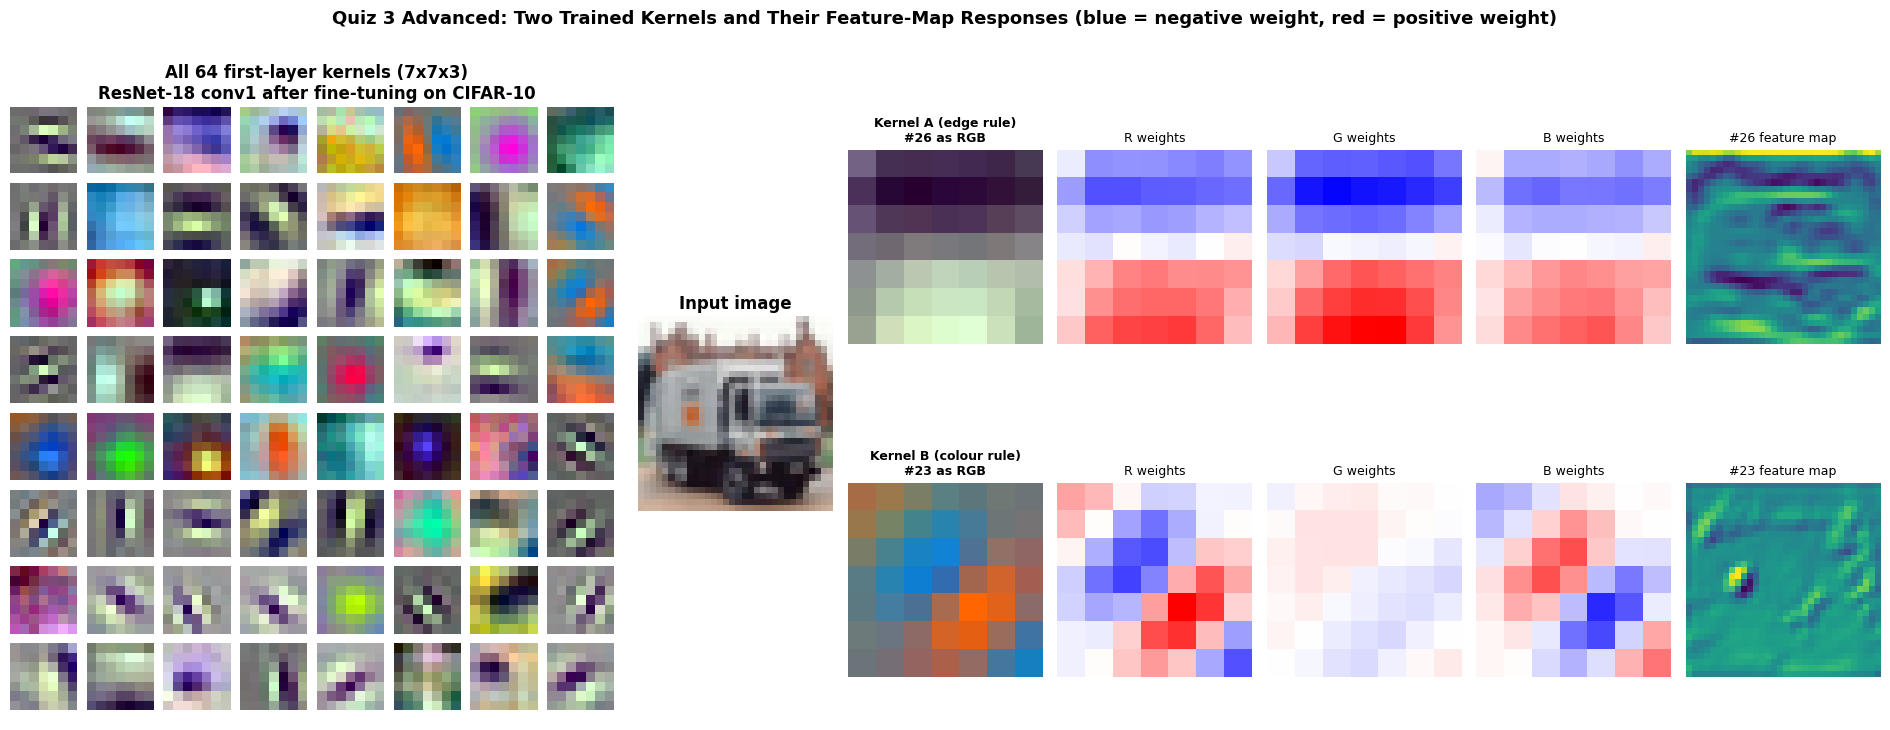

{'edge_idx': 26, 'colour_idx': 23, 'edge_stats': {'colour_ratio': 0.21206743270127215, 'orientation': 'horizontal edges (intensity changes top-bottom)', 'channel_mean_rgb': [0.0028, -0.0045, 0.0042], 'spatial_energy': 0.9225055250458265, 'mean_response_std': 4.4924}, 'colour_stats': {'colour_ratio': 0.9988887583783713, 'orientation': 'diagonal / mixed-direction structure', 'channel_mean_rgb': [-0.0013, -0.0033, 0.0002], 'spatial_energy': 0.06430629981887463, 'mean_response_std': 0.4518}, 'image_index': 11, 'image_class': 'truck'}


In [9]:
display(q3['figures']['kernels'])
print(q3['kernel_info'])

**XAI：Grad-CAM**（Selvaraju et al., 2017）
- 計算預測類別分數對卷積特徵圖的梯度，將梯度平均後作為各通道的權重，加權總和後經 ReLU，再放大疊回原圖。紅色區域代表最能提高該類別分數的位置。
- Plain CNN 使用 `block3`（8×8 特徵圖）；ResNet-18 使用 `layer3`（在 64×64 輸入下為 4×4）。`layer4` 只剩 2×2，空間解析度太低。
- 樣本依規則挑選：前 6 個類別中「兩個模型都答對」的影像各一張，另外 4 張是「兩個模型都答錯」的影像。
- 量化指標 `centre_mass`：Grad-CAM 熱圖落在影像中央 16×16（佔 25% 面積）的比例；若熱圖是均勻分佈，數值為 0.25。

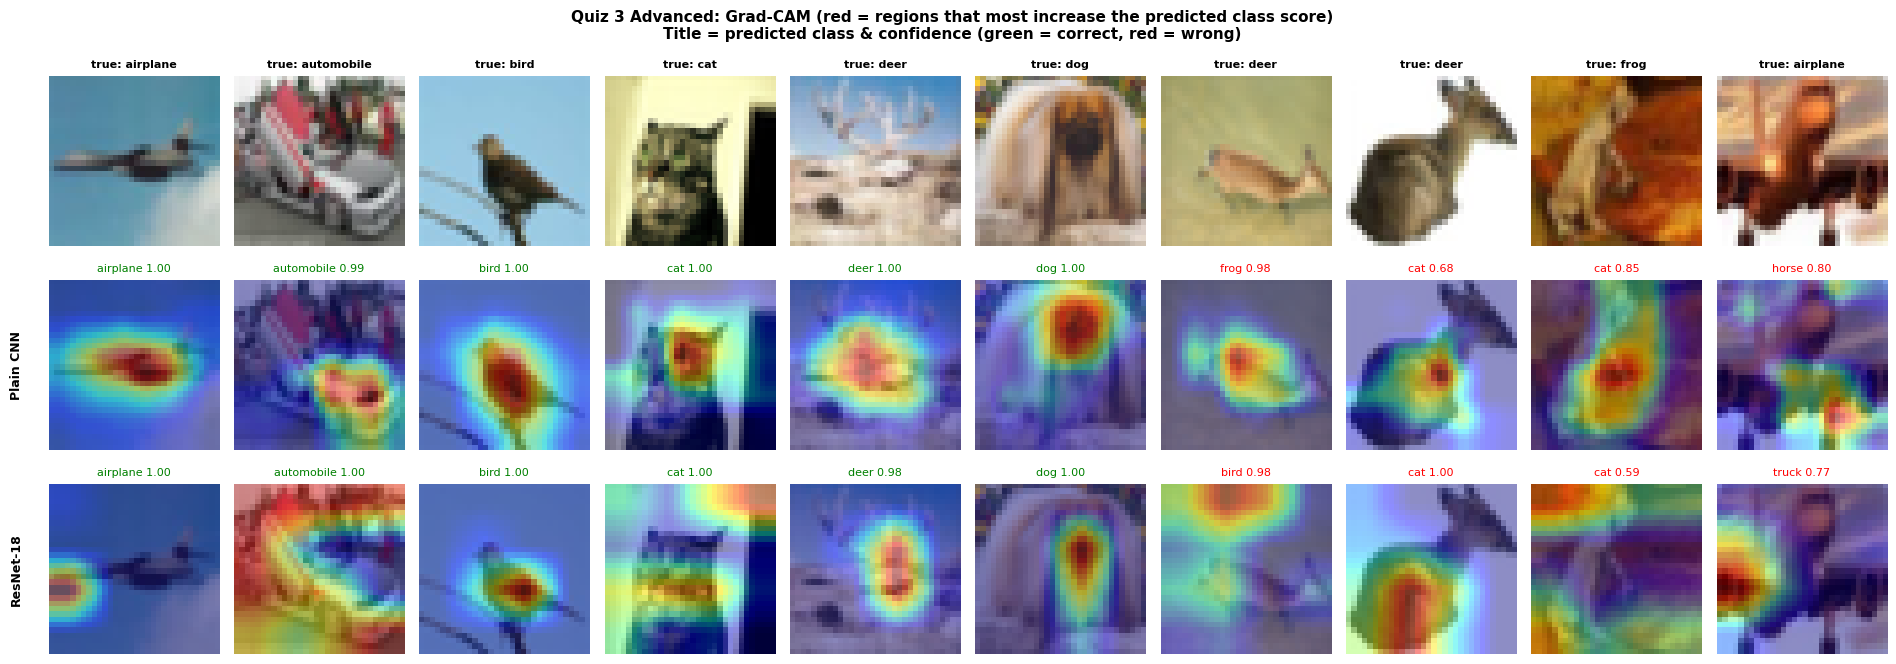

,index,model,true,pred,confidence,correct,centre_mass,feature_map
0,8777,Plain CNN,airplane,airplane,0.999,True,0.575,8x8
1,8777,ResNet-18,airplane,airplane,0.999,True,0.102,4x4
2,6371,Plain CNN,automobile,automobile,0.989,True,0.385,8x8
3,6371,ResNet-18,automobile,automobile,1.000,True,0.187,4x4
4,5032,Plain CNN,bird,bird,1.000,True,0.578,8x8
5,5032,ResNet-18,bird,bird,1.000,True,0.766,4x4
6,2617,Plain CNN,cat,cat,1.000,True,0.520,8x8
7,2617,ResNet-18,cat,cat,1.000,True,0.276,4x4
8,3054,Plain CNN,deer,deer,1.000,True,0.638,8x8
9,3054,ResNet-18,deer,deer,0.983,True,0.733,4x4


,model,correct,centre_mass
0,Plain CNN,False,0.540
1,Plain CNN,True,0.517
2,ResNet-18,False,0.230
3,ResNet-18,True,0.456


In [10]:
display(q3['figures']['gradcam'])
display(q3['gradcam_records'])
display(q3['gradcam_summary'])

---
## 結果分析

各題的數據解讀、實驗結論與限制說明，整理在同目錄的 `README.md`。

In [11]:
# 【實驗完成後打包下載】如果你是在 Colab 本地空間跑，執行這格會將成果打包並自動下載到你的電腦！
import os
try:
    import google.colab
    from google.colab import files
    !zip -q -r /content/HW03_completed.zip Output Checkpoints
    files.download('/content/HW03_completed.zip')
    print('已打包完成並觸發瀏覽器下載 HW03_completed.zip！')
except Exception as e:
    print(f'本地執行或下載略過: {e}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

已打包完成並觸發瀏覽器下載 HW03_completed.zip！
